In [8]:
import json
import gzip
import scanpy as sc
import pandas as pd
import numpy as np
import os
import anndata
import matplotlib.pyplot as plt

In [23]:
base_path = "/n/fs/ragr-data/users/viola/structuredVAE/"
adata_path = f"{base_path}/data/packer2019_preprocessed.h5ad"
paths_dict_path = "/n/fs/ragr-data/users/viola/mouse_dev/scripts/new_c_elegans/paths_dict_min15.json.gz"

lineage_key = "lineage"

output_json_path = f"{base_path}/data/lineage_cell_counts.json"

In [24]:
def load_path_dict(path: str):
    opener = gzip.open if path.endswith(".gz") else open
    with opener(path, "rt") as f:
        return json.load(f)

paths_dict = load_path_dict(paths_dict_path)


In [4]:
adata = sc.read_h5ad(adata_path)

if lineage_key not in adata.obs:
    raise KeyError(f"Column {lineage_key!r} not found in adata.obs. "
                   f"Available keys: {list(adata.obs.columns)}")

In [5]:
counts_series = adata.obs[lineage_key].value_counts(dropna=False)

# Convert to plain Python dict with string keys and int values
# (NaN will be converted to the string "NaN" if present)
lineage_counts = {str(k): int(v) for k, v in counts_series.items()}

In [18]:
path_lineage_counts = {}

for path_name, lineage_path in paths_dict.items():
    # lineage_path is expected to be a list of lineage labels
    per_path_counts = {}
    scvi_data_path = os.path.join(base_path, f"data/scvi_path_{path_name}", "trained.h5ad")
    if not os.path.exists(scvi_data_path):
        raise FileNotFoundError(
            f"Pre-trained scVI file not found: {scvi_data_path}\n"
            f"Please run scVI training first (e.g., scvi_celegan_path.py)"
        )
    
    data = anndata.read_h5ad(scvi_data_path)
    for label in data.obs.lineage:
        # Number of cells in adata with this lineage label
        count = int((adata.obs[lineage_key] == label).sum())
        per_path_counts[label] = count

    path_lineage_counts[path_name] = per_path_counts

# Save this as a separate JSON
output_json_path_per_path = f"{base_path}/data/lineage_cell_counts_per_path.json"
with open(output_json_path_per_path, "w") as f:
    json.dump(path_lineage_counts, f, indent=2)

print(f"Saved per-path lineage cell counts to: {output_json_path_per_path}")

Saved per-path lineage cell counts to: /n/fs/ragr-data/users/viola/structuredVAE//data/lineage_cell_counts_per_path.json


In [12]:
del lineage_counts["nan"]

In [19]:
path_lineage_counts

{'ABpla_ABplapaaaapa': {'ABpxapaaa': 86,
  'ABpxapaaaa': 123,
  'ABpxapaaaap': 109,
  'ABpxapaaaapa': 65,
  'ABpxapaa': 53,
  'ABpxax': 17,
  'ABpxapa': 9},
 'ABalaaa_ABalaaapprl': {'ABalaaapal/ABalaaappr': 146,
  'ABalaaapx': 44,
  'ABalaaapalr/ABalaaapprl': 55,
  'ABalaaap': 30,
  'ABalaax/ABalapxa': 15,
  'ABalaax': 5},
 'ABpr_ABpraapaapa': {'ABpxaapaap': 169,
  'ABpxaapaa': 99,
  'ABpxaapaapa': 79,
  'ABpxaapa': 53,
  'ABpxaap': 27,
  'ABpxax': 17},
 'P1_Cpappd': {'Cxapp': 75, 'Cxappd': 72, 'Cx': 14, 'Cxa': 6, 'Cxap': 13},
 'ABpr_ABprapppaaa': {'ABpxapppaa': 210,
  'ABpxapppa': 156,
  'ABpxappp': 49,
  'ABpxapppaaa': 31,
  'ABpxax': 17,
  'ABpxapp': 10},
 'ABpr_ABpraapapap': {'ABpxaapapa': 160,
  'ABpxaapap': 75,
  'ABpxaapapap': 51,
  'ABpxaapa': 53,
  'ABpxaap': 27,
  'ABpxax': 17},
 'ABa_ABarppaaaa': {'ABarppxaa': 47,
  'ABarppxaaa': 54,
  'ABarppx': 37,
  'ABarpx': 15,
  'ABaxx': 27,
  'ABarppxa': 4},
 'ABalapa_ABalapapppa': {'ABalapxppp': 103,
  'ABalapxpp': 43,
  'ABalapxp': 

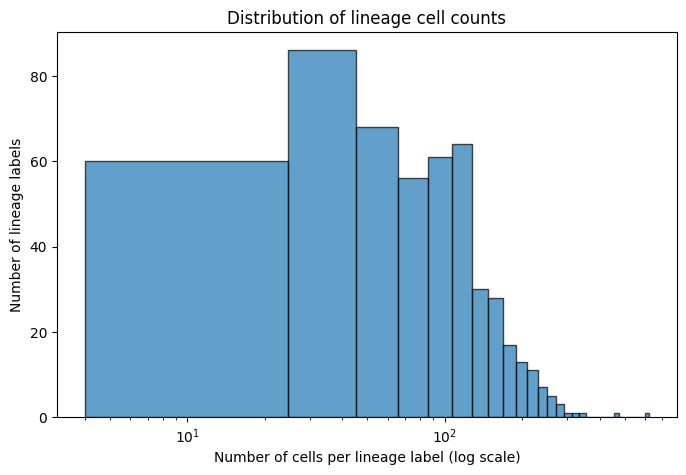

In [13]:
counts = np.array(list(lineage_counts.values()))

plt.figure(figsize=(8,5))
plt.hist(counts, bins=30, edgecolor="black", alpha=0.7)
plt.xscale('log')  # optional but recommended for skewed distributions
plt.xlabel("Number of cells per lineage label (log scale)")
plt.ylabel("Number of lineage labels")
plt.title("Distribution of lineage cell counts")
plt.show()

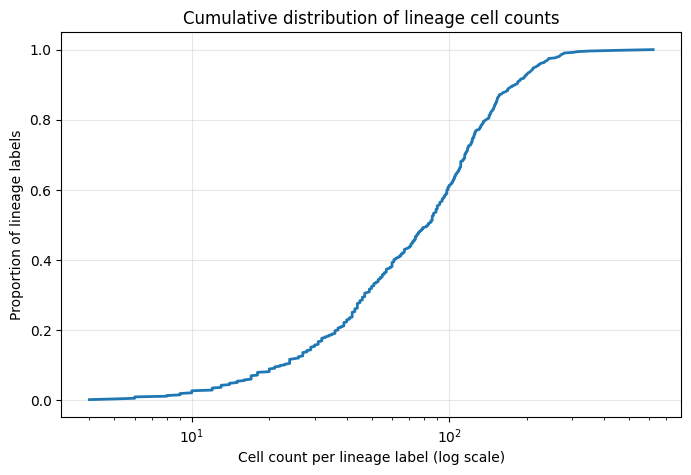

In [14]:
sorted_counts = np.sort(counts)
cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)

plt.figure(figsize=(8,5))
plt.plot(sorted_counts, cdf, linewidth=2)
plt.xscale("log")
plt.xlabel("Cell count per lineage label (log scale)")
plt.ylabel("Proportion of lineage labels")
plt.title("Cumulative distribution of lineage cell counts")
plt.grid(alpha=0.3)
plt.show()

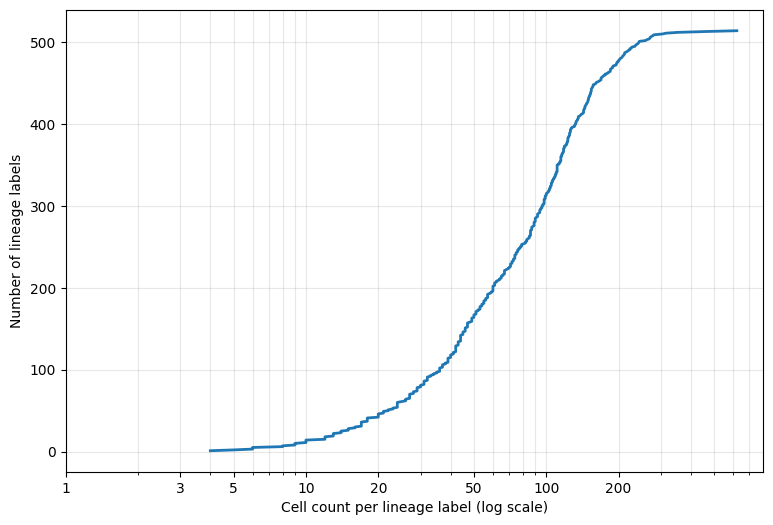

In [20]:
counts = np.array(list(lineage_counts.values()))
sorted_counts = np.sort(counts)

# y-axis is now "number of labels ≤ X"
cdf_labels = np.arange(1, len(sorted_counts)+1)

plt.figure(figsize=(9,6))
plt.plot(sorted_counts, cdf_labels, linewidth=2)

plt.xscale("log")
plt.xlabel("Cell count per lineage label (log scale)")
plt.ylabel("Number of lineage labels")
# plt.title("CDF of lineage cell counts")

# Add specific x-ticks for interpretation
xticks = [1, 3, 5, 10, 20, 50, 100, 200]
xticks = [t for t in xticks if t <= sorted_counts.max()]
plt.xticks(xticks, xticks)

plt.grid(alpha=0.3, which='both')
plt.show()


In [22]:
path_lineage_counts

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/n/fs/ragr-data/users/viola/structuredVAE//data/scvi_path_ABplaapa_ABplaapapppa/trained.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)